Mã trạng thái API trả về: 200


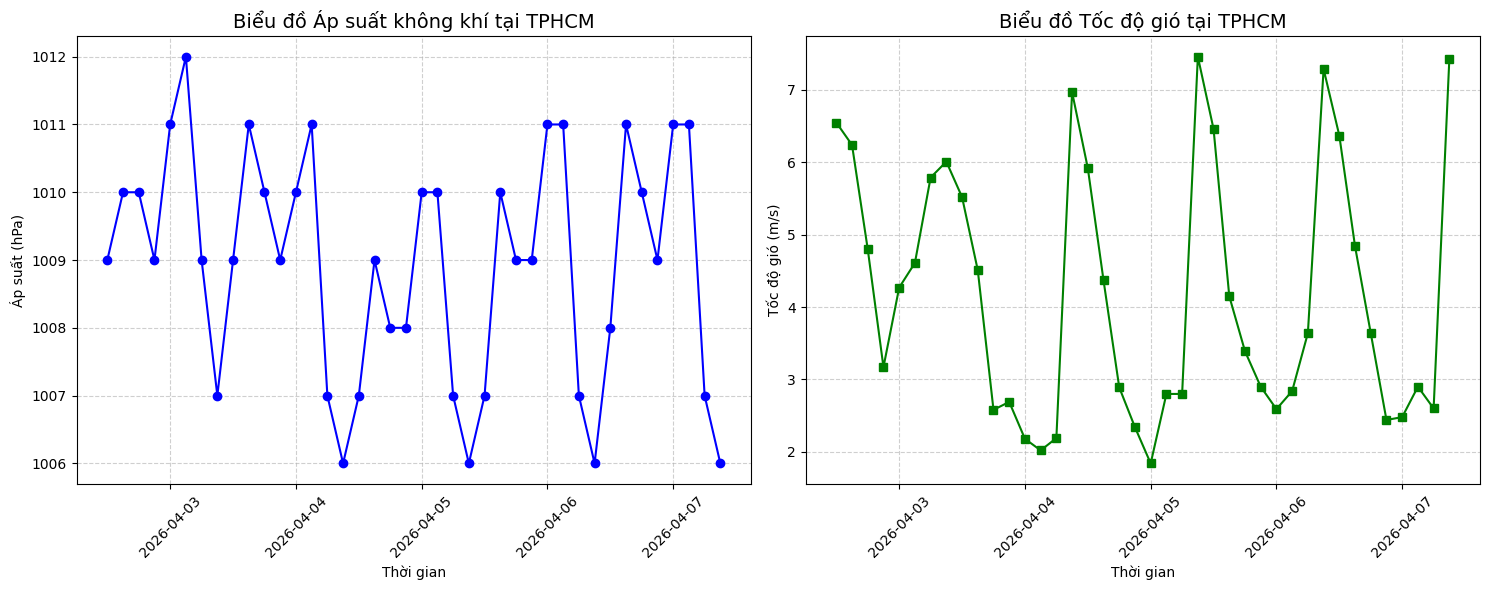

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

#Thiết lập thông tin API
#Mã zip không dùng được nên phải đổi sang tên thành phố để lấy dữ liệu thời tiết cho TPHCM
API_KEY = "b72e7baa47c43e19be50ad2fab266d84" 
CITY = "Ho Chi Minh City,vn" 


url = f"http://api.openweathermap.org/data/2.5/forecast?q={CITY}&appid={API_KEY}&units=metric"

#Gọi API và tải dữ liệu về
response = requests.get(url)
data = response.json()

print("Mã trạng thái API trả về:", data.get('cod')) 

#Trích xuất dữ liệu cần thiết
weather_list = data['list']

thoi_gian = []
ap_suat = []
toc_do_gio = []

for item in weather_list:
    thoi_gian.append(item['dt_txt'])             
    ap_suat.append(item['main']['pressure'])     
    toc_do_gio.append(item['wind']['speed'])     

df_weather = pd.DataFrame({
    'Time': pd.to_datetime(thoi_gian),
    'Pressure': ap_suat,
    'Wind_Speed': toc_do_gio
})

#Vẽ biểu đồ áp suất và tốc độ gió
plt.figure(figsize=(15, 6))

#Biểu đồ áp suất
plt.subplot(1, 2, 1) 
plt.plot(df_weather['Time'], df_weather['Pressure'], marker='o', color='blue')
plt.title('Biểu đồ Áp suất không khí tại TPHCM', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Áp suất (hPa)')
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.6)

#Biểu đồ tốc độ gió
plt.subplot(1, 2, 2) 
plt.plot(df_weather['Time'], df_weather['Wind_Speed'], marker='s', color='green')
plt.title('Biểu đồ Tốc độ gió tại TPHCM', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Tốc độ gió (m/s)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()